In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
import sys
from pathlib import Path


PROJECT_ROOT = Path("/content/drive/MyDrive/master-thesis").resolve()
SRC_PATH = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / 'data/13_years'

os.chdir(PROJECT_ROOT)

Mounted at /content/drive


In [2]:
from sklearn.metrics import mean_squared_error
from math import sqrt
import pandas as pd
import sys
from notebooks.utils import get_predictions, get_predictions_transformer, get_predictions_quarterly_models, plot_average_predictions

In [ ]:
tickers = ['GOOGL', 'AMZN', 'AAPL', 'PEP', 'JNJ', 'PFE', 'MRK', 'ABBV', 'PG', 'KO',
           'WMT', 'JPM', 'BAC', 'GS', 'V', 'XOM', 'CVX', 'COP', 'BP', 'BA',
           'MMM', 'HON', 'GE', 'T', 'VZ', 'TMUS', 'HSY', 'DUK', 'SO', 'EXC', 'AEP',
           'AMT', 'PLD', 'SPG', 'BHP', 'RIO', 'VALE', 'FCX']
           
simulation_start_date = '2021-01-01'
simulation_end_date = '2023-10-23'

sequence_length = 50

quarterly_data_start_date = '2013-01-01'
data_end_date = '2023-10-23'

# LSTM 13 years training

In [4]:
MODEL_DIR = PROJECT_ROOT / 'notebooks/models/LSTM_13_years'
PLOTS_DIR = PROJECT_ROOT / 'notebooks/plots/baseline/LSTM_13_years'

In [5]:
predictions, actuals = get_predictions(
    tickers,
    simulation_start_date,
    simulation_end_date,
    sequence_length,
    MODEL_DIR,
    use_partition_dataset=False,
)

Processing GOOGL...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Processing AMZN...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Processing AAPL...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Processing PEP...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Processing JNJ...


...

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Processing BHP...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Processing RIO...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Processing VALE...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Processing FCX...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [6]:
def calculate_rmse_for_all_tickers(actuals, predictions):
    rmse_values = {}
    for ticker in actuals.keys():
        actual = actuals[ticker]
        pred = predictions[ticker]
        rmse = sqrt(mean_squared_error(actual, pred))
        rmse_values[ticker] = rmse
        print(f"RMSE for {ticker}: {rmse}")
    return rmse_values

rmse_values = calculate_rmse_for_all_tickers(actuals, predictions)

RMSE for GOOGL: 7.545291184498927
RMSE for AMZN: 10.270048921318944
RMSE for AAPL: 4.778486611817047
RMSE for PEP: 3.8304293375832277
RMSE for JNJ: 2.897009832280138
RMSE for PFE: 1.3176179727850137
RMSE for MRK: 4.870406802472247
RMSE for ABBV: 7.264887692093202
RMSE for PG: 2.586313343709158
RMSE for KO: 0.9458219875782493
RMSE for WMT: 0.8912499522598779
RMSE for JPM: 6.621022616696314
RMSE for BAC: 2.567510915950257
RMSE for GS: 13.523782525260453
RMSE for V: 5.910237386189542
RMSE for XOM: 18.54731779151897
RMSE for CVX: 8.15788490313917
RMSE for COP: 10.916532753953025
RMSE for BP: 1.3696455056360166
RMSE for BA: 6.659686848589445
RMSE for MMM: 6.796243212656094
RMSE for HON: 3.7081383038682
RMSE for GE: 1.8370454469812412
RMSE for T: 0.5177173124532886
RMSE for VZ: 2.855722102233969
RMSE for TMUS: 2.9215413790371434
RMSE for HSY: 10.893250745793354
RMSE for DUK: 1.947926705831417
RMSE for SO: 1.304385254928161
RMSE for EXC: 2.98718552590444
RMSE for AEP: 1.6886581944847203
RMSE 

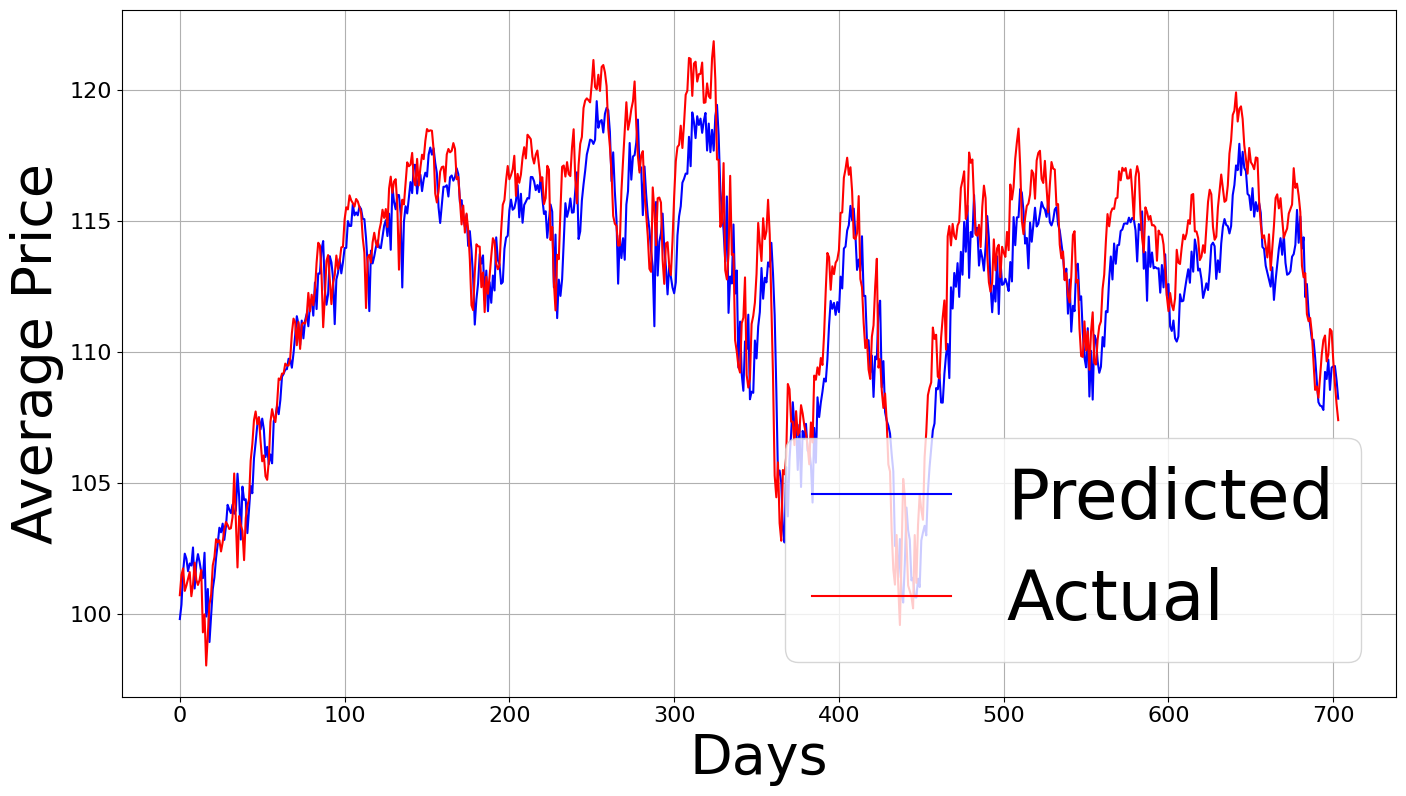

In [7]:
plot_average_predictions(predictions, actuals, PLOTS_DIR)

# LSTM 3 years training

In [4]:
MODEL_DIR = PROJECT_ROOT / 'notebooks/models/LSTM_3_years'
PLOTS_DIR = PROJECT_ROOT / 'notebooks/plots/baseline/LSTM_3_years'

In [5]:
predictions, actuals = get_predictions(
    tickers,
    simulation_start_date,
    simulation_end_date,
    sequence_length,
    MODEL_DIR,
    use_partition_dataset=False,
)

Processing GOOGL...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Processing AMZN...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Processing AAPL...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Processing PEP...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Processing JNJ...


...

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Processing BHP...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


Processing RIO...
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Processing VALE...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Processing FCX...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [6]:
def calculate_rmse_for_all_tickers(actuals, predictions):
    rmse_values = {}
    for ticker in actuals.keys():
        actual = actuals[ticker]
        pred = predictions[ticker]
        rmse = sqrt(mean_squared_error(actual, pred))
        rmse_values[ticker] = rmse
        print(f"RMSE for {ticker}: {rmse}")
    return rmse_values

rmse_values = calculate_rmse_for_all_tickers(actuals, predictions)

RMSE for GOOGL: 9.254758141680831
RMSE for AMZN: 6.26889496829649
RMSE for AAPL: 5.098778253992553
RMSE for PEP: 3.630189279918687
RMSE for JNJ: 3.1370279793942397
RMSE for PFE: 1.2613449077124932
RMSE for MRK: 5.349760345014997
RMSE for ABBV: 5.67234479323122
RMSE for PG: 2.4069925095530773
RMSE for KO: 0.9301010994692396
RMSE for WMT: 0.8855407870488939
RMSE for JPM: 4.535821622025895
RMSE for BAC: 2.0378465647032526
RMSE for GS: 27.620240139946738
RMSE for V: 5.37023488564283
RMSE for XOM: 13.296036171802402
RMSE for CVX: 6.760722447409458
RMSE for COP: 9.405603056693696
RMSE for BP: 1.1948387846009543
RMSE for BA: 6.633840228968718
RMSE for MMM: 7.756269671254594
RMSE for HON: 3.8541226888931224
RMSE for GE: 2.0026730841747504
RMSE for T: 0.649208397391569
RMSE for VZ: 2.901806361769619
RMSE for TMUS: 2.9467654117126307
RMSE for HSY: 9.741057967539527
RMSE for DUK: 1.952428018976987
RMSE for SO: 1.3539066523348873
RMSE for EXC: 2.380104786604746
RMSE for AEP: 1.6831236966794472
RMS

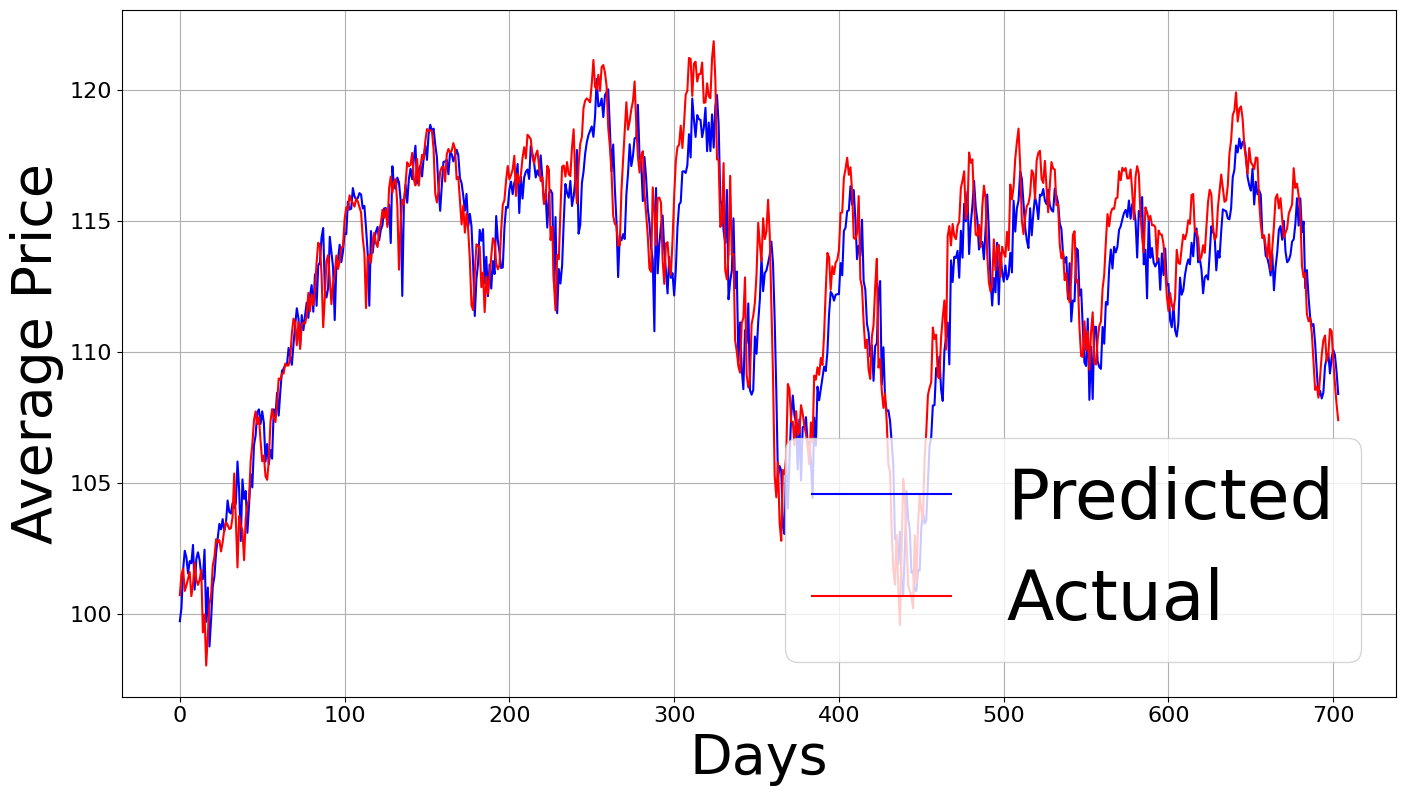

In [7]:
plot_average_predictions(predictions, actuals, PLOTS_DIR)

# LSTM quarterly cumulative retrain

In [12]:
MODEL_DIR = PROJECT_ROOT / 'notebooks/models/LSTM_cumulative'
PLOTS_DIR = PROJECT_ROOT / 'notebooks/plots/baseline/LSTM_cumulative'

In [ ]:
predictions, actuals = get_predictions_quarterly_models(
    tickers,
    simulation_start_date,
    simulation_end_date,
    sequence_length,
    model_folder=MODEL_DIR,
    data_start=quarterly_data_start_date,
    train_mode="cumulative"
)

In [ ]:
def calculate_rmse_for_all_tickers(actuals, predictions):
    rmse_values = {}
    for ticker in actuals.keys():
        actual = actuals[ticker]
        pred = predictions[ticker]
        rmse = sqrt(mean_squared_error(actual, pred))
        rmse_values[ticker] = rmse
        print(f"RMSE for {ticker}: {rmse}")
    return rmse_values

rmse_values = calculate_rmse_for_all_tickers(actuals, predictions)

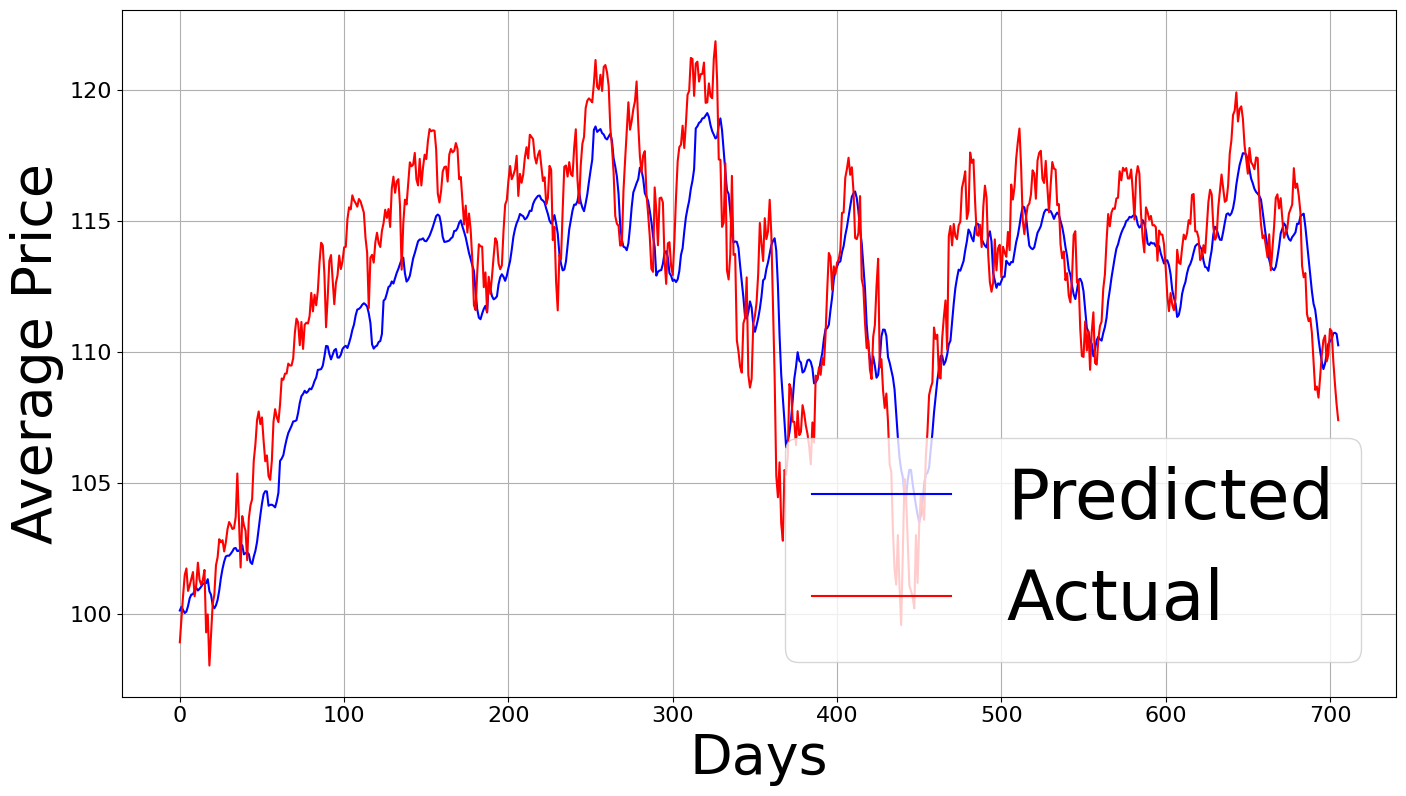

In [15]:
plot_average_predictions(predictions, actuals, PLOTS_DIR)

# LSTM quarterly rolling retrain

In [16]:
MODEL_DIR = PROJECT_ROOT / 'notebooks/models/LSTM_rolling'
PLOTS_DIR = PROJECT_ROOT / 'notebooks/plots/baseline/LSTM_rolling'

In [ ]:
predictions, actuals = get_predictions_quarterly_models(
    tickers,
    simulation_start_date,
    simulation_end_date,
    sequence_length,
    model_folder=MODEL_DIR,
    data_start=quarterly_data_start_date,
    train_mode="rolling"
)

In [18]:
def calculate_rmse_for_all_tickers(actuals, predictions):
    rmse_values = {}
    for ticker in actuals.keys():
        actual = actuals[ticker]
        pred = predictions[ticker]
        rmse = sqrt(mean_squared_error(actual, pred))
        rmse_values[ticker] = rmse
        print(f"RMSE for {ticker}: {rmse}")
    return rmse_values

rmse_values = calculate_rmse_for_all_tickers(actuals, predictions)

RMSE for GOOGL: 6.940837142971015
RMSE for AMZN: 7.653894858359661
RMSE for AAPL: 6.2913453067342315
RMSE for PEP: 3.840906359112266
RMSE for JNJ: 3.3868686913662702
RMSE for PFE: 2.3886274951650988
RMSE for MRK: 2.0731103873940913
RMSE for ABBV: 5.146624090858824
RMSE for PG: 4.374652610871994
RMSE for KO: 1.4098049493526799
RMSE for WMT: 1.3969870857197149
RMSE for JPM: 10.675718591599054
RMSE for BAC: 2.5401760752471225
RMSE for GS: 14.526328027916538
RMSE for V: 6.071287797488956
RMSE for XOM: 4.081506474834519
RMSE for CVX: 9.10562364268218
RMSE for COP: 4.437925857766681
RMSE for BP: 0.986066310107617
RMSE for BA: 8.515574349391157
RMSE for MMM: 4.369654121989975
RMSE for HON: 5.799599396619427
RMSE for GE: 5.80388575603358
RMSE for T: 0.8015157451442434
RMSE for VZ: 1.0166824153946004
RMSE for TMUS: 4.643465070645345
RMSE for HSY: 6.016665343686864
RMSE for DUK: 2.626305583940978
RMSE for SO: 2.328509971581168
RMSE for EXC: 1.5082731192604935
RMSE for AEP: 3.5650536596136977
RMS

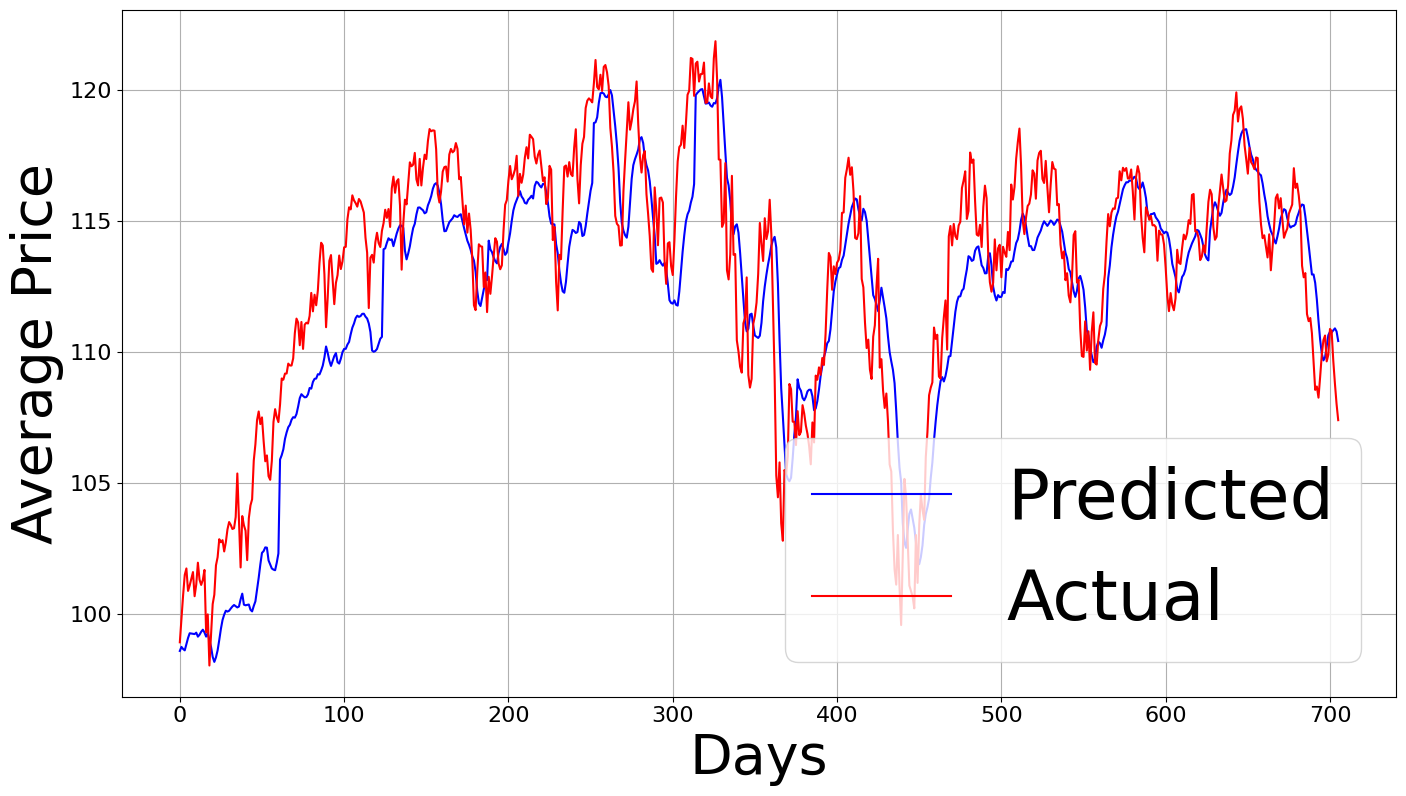

In [19]:
plot_average_predictions(predictions, actuals, PLOTS_DIR)